In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from sklearn.metrics import r2_score
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

## <u>Steps</u>

1. Load data
2. Train test split
3. Scale the data (important for NN)
4. Convert data into pytorch tensors (vvimp)
5. Create tensor dataset and data loader
6. Define ANN model (not a 2 step process like traditional ML methods, we define a whole class)
7. Train the model (training also not that simple, have to define the sequence for each step)
8. Save the model (optional)
9. Evaluation

---
## <u>Load Dataset</u>

**Features :-**
- AT => temperature
- V &nbsp;=> vacuum
- AP => pressure
- RH => humidity

**Label :-**
- PE => produced energy

4 neurons in the input layer (one per feature) and 1 neuron in the output layer (regression target).

In [2]:
data = pd.read_csv("powerplant_data.csv")
data.shape # (9568, 5)
data.isnull().sum() # no null values
data.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


---
## <u>Train Test Split & Scaling</u>

In [3]:
X = data.drop(columns = ["PE"])
y = data["PE"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
scaler.set_output(transform = "pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---
## <u>Convert to PyTorch Tensors</u>

Tensors are the core data structure of pytorch, like N-Dimensional arrays in numpy (1d, 2d, 3d, 4d+). Once we convert into tensors, pytorch can calculate gradients for us. All 4 tensors below are stored in RAM.

We use `torch.tensor()` to convert:
- Anything that's still a pandas DataFrame/Series needs `.values` first.
- Anything already plain numpy doesn't.

`.view(rows, cols)` changes the dimensions of a pytorch tensor. The current shape of `y_train` is `(n,)` i.e. a 1D array/series, but pytorch tensors expect the shape to be `(n,1)` i.e. 2D.
- `-1` rows means automatically detect the number of rows, since `n` depends on the dataset and test size.
- `1` col makes it a shape of `(n,1)`.

In [4]:
X_train_tensor = torch.tensor(X_train_scaled.values, dtype = torch.float32) # all our values are float only
X_test_tensor = torch.tensor(X_test_scaled.values, dtype = torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype = torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.float32).view(-1, 1)

---

## <u>Architecture Design</u>

We decide the architecture of the NN as well, meaning how many neurons, layers etc.

- We randomly choose 2 hidden layers with 6 neurons each
- This type of model is called sequential, meaning all the layers come in sequence one by one
- Therefore, the whole architecture is 4 layers :-
    - input layer (4 neurons)
    - hidden layer 1 (6 neurons)
    - hidden layer 2 (6 neurons)
    - output layer (1 neuron)

---
## <u>Build TensorDataset & DataLoader</u>

Currently the tensors are stored in RAM. Pytorch has a class called `DataLoader`, whose job is to create mini batches from the whole dataset stored as a tensor in RAM. It also shuffles the tensors/batches around (optional). In formal words, `DataLoader` defines **how** the data will be loaded for training the ANN.

The problem is that `DataLoader` cannot directly access the dataset stored as raw tensors. For that we use a helper class called `TensorDataset`, which can access the dataset directly. It zips X_train_tensor and y_train_tensor together, index-for-index. Row i of X is now permanently linked to row i of y as one retrievable unit.

Chain: raw tensors ---> `TensorDataset` (pairs X with y) ----> `DataLoader` (batches, shuffles)

In [5]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor) # in_features, out_features
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True) # Wraps train_dataset into an iterable that gives 32 rows at a time
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False) 

---
## <u>Define ANN Model</u>

We build the ANN as a class, based on another class called `nn.Module`. No need to initialise weights and bias, that is done by pytorch automatically.

1. Make the constructor, and use the `super` keyword to call the constructor of the `nn.Module` class.
2. Define the actual model using the `self` keyword for the object made by the class.
3. Define how the forward propagation should occur (no need for a separate function for backward propagation — pytorch handles that via autograd).

In each hidden layer we first calculate the Z value (weighted sum) using the `Linear` function, then apply the `ReLU` activation on it. In regression, the output layer just uses a plain linear function (no activation).

In [6]:
class ANN_Regressor(nn.Module):

    def __init__(self): # self for the object of the class
        super(ANN_Regressor, self).__init__()

        self.model = nn.Sequential(
           
            # hidden layer 1
            nn.Linear(X_train_tensor.shape[1], 6), # input features = 4, output features = 6
            nn.ReLU(),

            # hidden layer 2
            nn.Linear(6, 6),
            nn.ReLU(),

            # output layer
            nn.Linear(6, 1) # linear only (regression)
        )

    def forward(self, x):
        return self.model(x) # passes input through the sequential model

---
## <u>Compile the Model</u>

We will track 3 values for the loss:
1. `batch_loss` — loss for 1 batch
2. `total_train_loss` — summed loss across all batches in 1 epoch
3. `avg_train_loss` — average loss per batch = `total_train_loss / len(batches)`, this is what we actually plot per epoch

In [7]:
model = ANN_Regressor()

loss_func = nn.MSELoss()
optimizer = optim.Adam(model.parameters()) # pass all the parameters of the model

---

## <u>Train the Model</u>

We train on the training dataset using multiple epochs — 100 epochs, i.e. we show the model the entire dataset 100 times. In every epoch, we iterate over multiple batches.

Variable names below, renamed for clarity:
- `batch_X`, `batch_y` — the features/labels for the current batch (previously `xb`, `yb`)
- `y_pred` — the model's predicted output for the current batch (previously `y`)
- `batch_loss` — loss for the current batch (previously `loss`)
- `total_train_loss` / `total_val_loss` — summed loss across all batches in the current epoch
- `avg_train_loss` / `avg_val_loss` — average loss per batch for the current epoch (previously `epoch_train_loss` / `epoch_val_loss`)
- `train_loss_history` / `val_loss_history` — the avg loss recorded per epoch, across all epochs (previously `training_losses` / `validation_losses`)

---
## <u>Saving the Best Model — how it works</u>

`best_val_loss = float("inf")` starts as infinity, just so the very first epoch is guaranteed to "beat" it.

Every epoch, we check: did this epoch's validation loss beat the lowest one seen so far?
- **Yes** → update `best_val_loss`, and overwrite `best_model.pt` with a full snapshot of the model's current weights (`model.state_dict()`).
- **No** → do nothing. The file keeps whatever it already had.

**Important:** `best_model.pt` is not a mix of the best individual weights from different epochs, that would be meaningless, since weights only make sense together as a set. It's always **one complete, consistent snapshot from a single epoch**, whichever epoch had the lowest val loss so far.

**Example:**

| Epoch | val loss | beats best so far? | best_model.pt now holds |
|---|---|---|---|
| 1 | 18.4 | yes (beats ∞) | epoch 1's weights |
| 2 | 12.1 | yes | epoch 2's weights (overwritten) |
| 3 | 13.7 | no | still epoch 2's weights |
| 4 | 11.9 | yes | epoch 4's weights (overwritten) |

By the end of training, the file holds the full weights from whichever epoch generalized best — useful because validation loss can start rising again (overfitting) even while training loss keeps dropping, so the last epoch isn't always the best one.

In [8]:
train_loss_history = []
val_loss_history = []
best_val_loss = float("inf") # infinity as a number

epochs = 100

for epoch in range(epochs):

    # training
    model.train() # 1. put the model into training mode, flips internal flags used by layers like Dropout/BatchNorm
    total_train_loss = 0.0 # training loss for this epoch

    for batch_X, batch_y in train_loader: # train_loader wraps our tensors into batches
        optimizer.zero_grad() # reset previous batch's gradients

        y_pred = model(batch_X) # predicted outputs for this batch
        batch_loss = loss_func(y_pred, batch_y) # compute loss, a tensor value
        batch_loss.backward() # backpropagation to compute the gradients
        optimizer.step() # adjust weights and bias accordingly
        total_train_loss = total_train_loss + batch_loss.item() # .item() converts tensor to float

    avg_train_loss = total_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    # validation
    model.eval() # 1. put the model into eval mode
    total_val_loss = 0.0

    with torch.no_grad(): # no gradients needed during validation
        for batch_X, batch_y in test_loader:
            y_pred = model(batch_X)
            batch_loss = loss_func(y_pred, batch_y)
            total_val_loss = total_val_loss + batch_loss.item()

    avg_val_loss = total_val_loss / len(test_loader)
    val_loss_history.append(avg_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {avg_train_loss} & val loss = {avg_val_loss}")

    # Saving the best performing model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        # saving the best model in the form of a dictionary, model.state_dict() has the current values for weights and biases
        torch.save(model.state_dict(), "best_model_regression.pt") # .pt or .pth

epoch 1/100 ==> train loss = 205982.89192708334 & val loss = 204247.1125
epoch 2/100 ==> train loss = 199192.44127604167 & val loss = 190693.34739583332
epoch 3/100 ==> train loss = 174051.01399739584 & val loss = 153148.57994791667
epoch 4/100 ==> train loss = 126415.33567708333 & val loss = 99231.62890625
epoch 5/100 ==> train loss = 72634.39010416667 & val loss = 50233.499609375
epoch 6/100 ==> train loss = 36961.85673421224 & val loss = 28343.073795572916
epoch 7/100 ==> train loss = 24266.44325358073 & val loss = 21388.5732421875
epoch 8/100 ==> train loss = 19401.38358968099 & val loss = 17495.24431966146
epoch 9/100 ==> train loss = 15810.921276855468 & val loss = 13992.997672526042
epoch 10/100 ==> train loss = 12390.28408203125 & val loss = 10702.776448567709
epoch 11/100 ==> train loss = 9349.390450032552 & val loss = 7991.262459309896
epoch 12/100 ==> train loss = 6848.343840535482 & val loss = 5713.273116048177
epoch 13/100 ==> train loss = 4778.205840047201 & val loss = 38

---
## <u>Plot the Loss Curves</u>

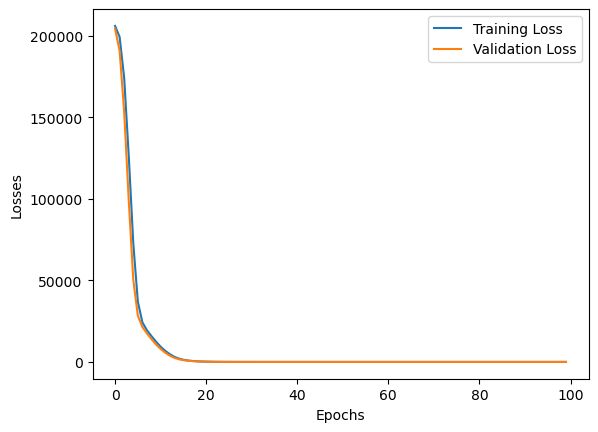

In [9]:
loss_df = pd.DataFrame({
    "Training Loss": train_loss_history,
    "Validation Loss": val_loss_history
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()
plt.show()

---

## <u>Loading The Best Model<u>

- We can now retrieve the best ``weights`` and `bias` values directly
- Then we put them in our model architecture to get the model with best parameters
- This model is the one where the ``validation loss`` is the least
- `weights_only=True` means "only allow loading plain tensors (weights, biases, buffers — anything numeric), block any executable Python objects," so all your weights *and* biases still load normally.

In [10]:
model.load_state_dict(torch.load("best_model_regression.pt", weights_only=True))

<All keys matched successfully>

---
## <u>Evaluation<u>

- we will compute:-

  1. Training MSE
  2. Testing MSE
  3. R2 score for testing

**Steps are pretty same like the validation evaluation we did earlier**

In [11]:
# 1. go into evaluation mode
model.eval()

# 2. make sure we calculate no gradients and make direct predictions
with torch.no_grad():
    y_train_pred = model(X_train_tensor) # for training predictions
    y_test_pred = model(X_test_tensor) # for testing predictions

    # 3. use already defined loss_func to calculate MSE
    train_mse_loss = loss_func(y_train_pred, y_train_tensor) # predicted values, true values
    test_mse_loss = loss_func(y_test_pred, y_test_tensor) 

    # 4. Calculate R2 score
    r2 = r2_score(y_test_tensor.numpy(), y_test_pred.numpy()) # true values, predicted values [r2 score allows NumPy arrays or plain Python lists]

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())
print("r^2 score =", r2)

Training MSE: 21.34061050415039
Testing MSE: 19.59899139404297
r^2 score = 0.9315065741539001


---

## <u>Putting the predictions and true values in a df side by side [OPTIONAL]<u>

In [12]:
predicted_df = pd.DataFrame({
    "Predicted Values" : y_test_pred.numpy().flatten(), # using .flatten to put it back into (n,) shape from (n,1)
    "Actual Values" : y_test_tensor.numpy().flatten()
})

predicted_df

,Predicted Values,Actual Values
0,435.135406,433.269989
1,436.784576,438.160004
2,460.972351,458.420013
3,475.967743,480.820007
4,435.078033,441.410004
...,...,...
1909,451.175812,456.700012
1910,431.474854,438.040009
1911,467.496948,467.799988
1912,430.914276,437.140015
